In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_path='/content/drive/MyDrive/CSE-4630(PR)/Covid19-dataset'
data_path_train ='/content/drive/MyDrive/CSE-4630(PR)/Covid19-dataset/train'
data_path_test ='/content/drive/MyDrive/CSE-4630(PR)/Covid19-dataset/test'

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
generator_train = ImageDataGenerator(
                                     interpolation_order=1,
                                     fill_mode='bilinear',
                                     rescale=1./255,
                                     validation_split=0.0,
                                     dtype=None)
generator_test = ImageDataGenerator(
                                    interpolation_order=1,
                                     fill_mode='bilinear',
                                     rescale=1./255,
                                     validation_split=0.0,
                                     dtype=None)

In [ ]:
train=generator_train.flow_from_directory('/content/drive/MyDrive/CSE-4630(PR)/Covid19-dataset/train', target_size=(64,64), batch_size=32, class_mode="categorical", color_mode='rgb')
test=generator_test.flow_from_directory('/content/drive/MyDrive/CSE-4630(PR)/Covid19-dataset/test', target_size=(64,64), batch_size=32, class_mode="categorical", color_mode='rgb')


Found 251 images belonging to 3 classes.
Found 66 images belonging to 3 classes.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

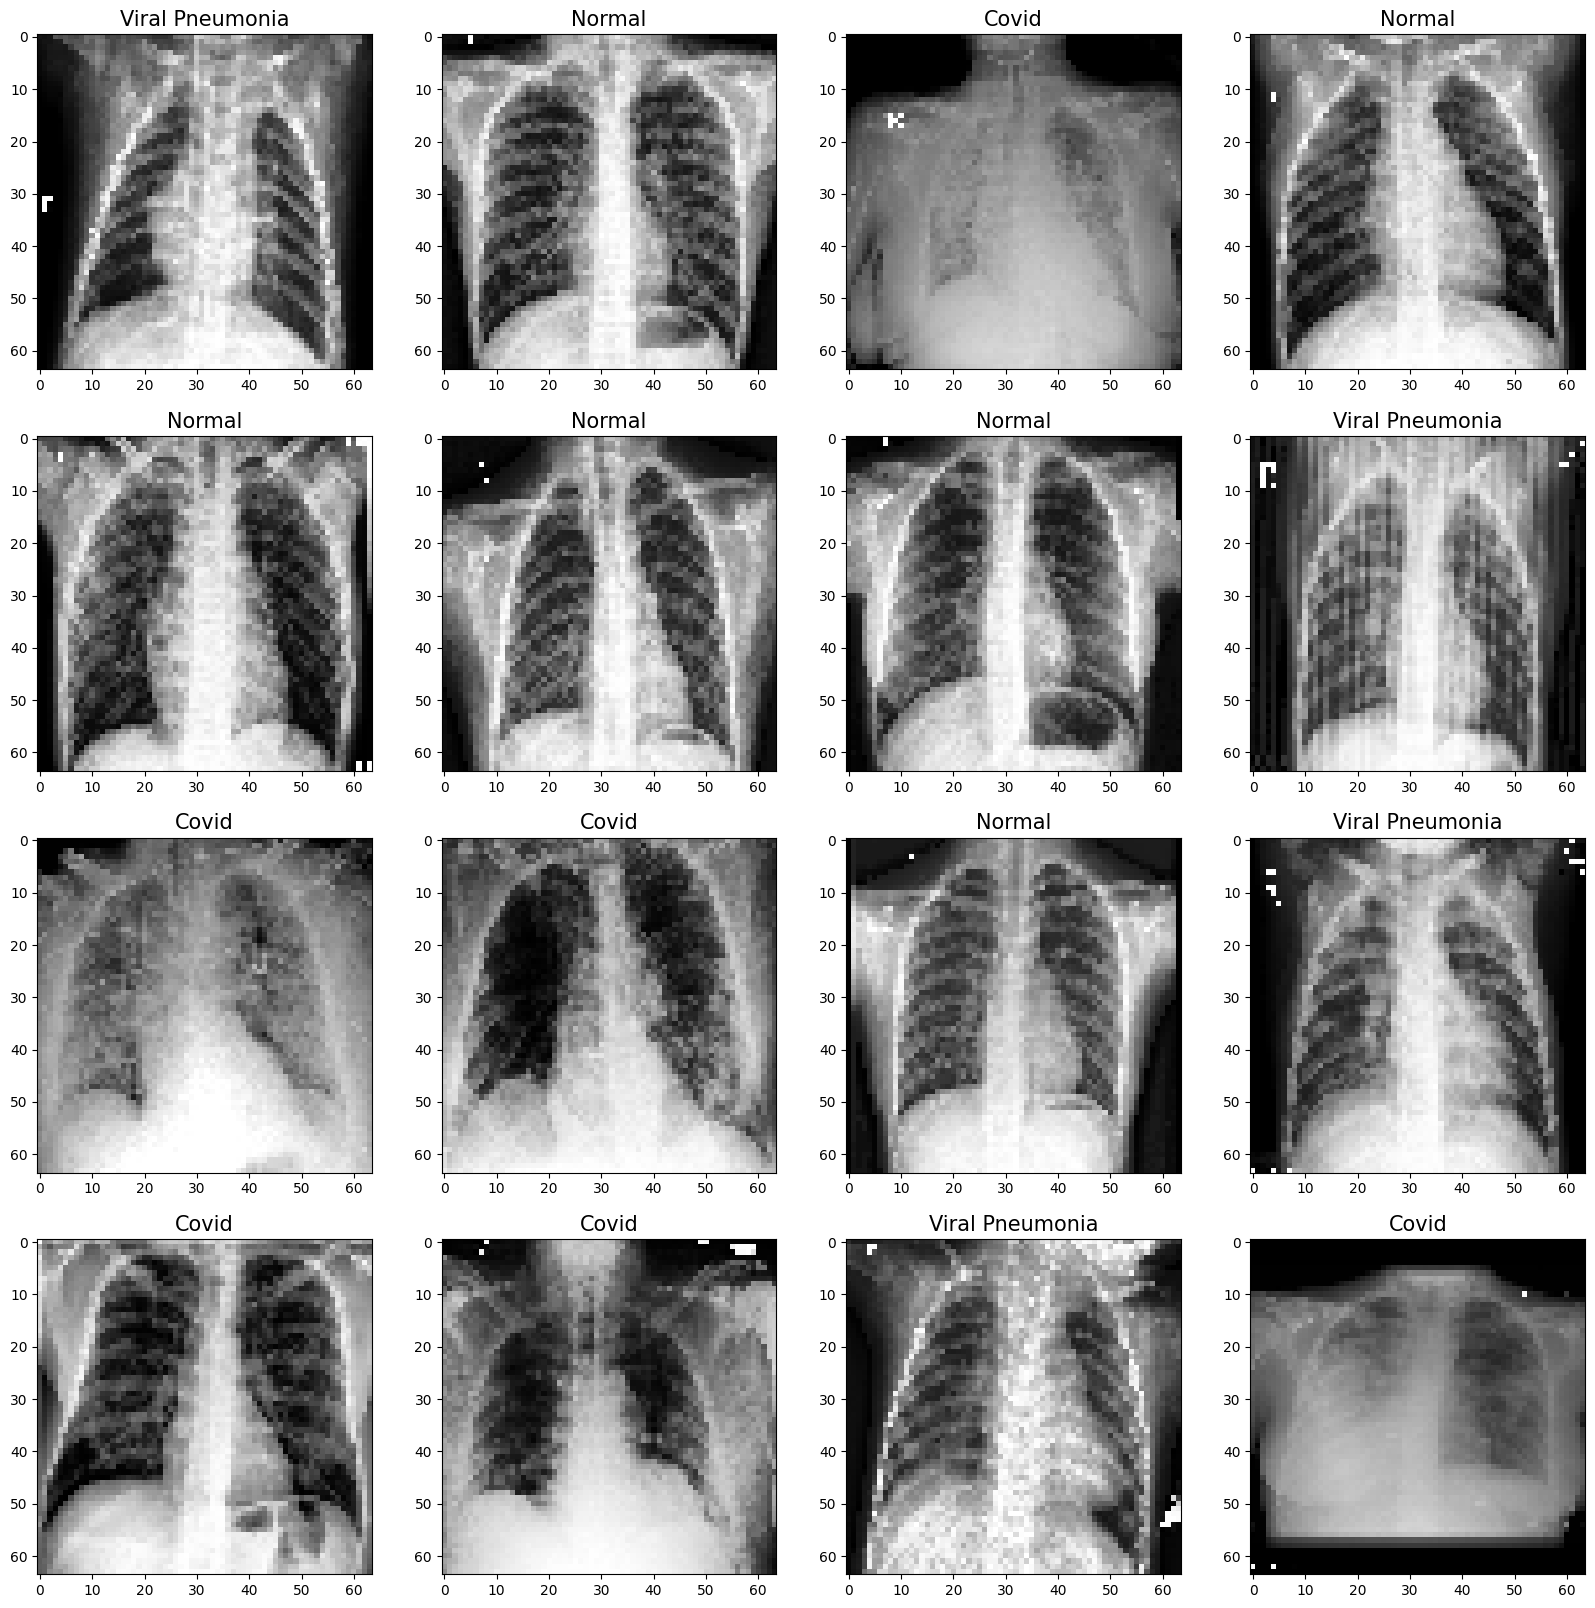

In [ ]:
class_dict = train.class_indices
classes = list(class_dict.keys())
images, labels = next(train)
plt.figure(figsize =(20,20))

for i in range(16):
  plt.subplot(4,4,i+1)
  image = images[i]
  plt.imshow(image)
  index = np.argmax(labels[i])
  class_name = classes[index]
  plt.title(class_name, color='k', fontsize=15)
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras


In [ ]:
img_height, img_width=256,256
input_shape=(256,256)
batch_size=32
test_ds=tf.keras.preprocessing.image_dataset_from_directory(

    data_path_test,
    validation_split=0.2,
    subset="training",
    seed=123,
    label_mode='categorical',
    image_size=(img_height,img_width),
    batch_size=batch_size
)

Found 66 files belonging to 3 classes.
Using 53 files for training.


In [ ]:
img_height, img_width=256,256
input_shape=(256,256)
batch_size=32
train_ds=tf.keras.preprocessing.image_dataset_from_directory(

    data_path_train,
    validation_split=0.2,
    subset="training",
    seed=123,
    label_mode='categorical',
    image_size=(img_height,img_width),
    batch_size=batch_size
)


Found 251 files belonging to 3 classes.
Using 201 files for training.


In [ ]:
val_ds=tf.keras.preprocessing.image_dataset_from_directory(
    data_path_train,
    validation_split=0.2,
    subset="validation",
    seed=123,
    label_mode='categorical',
    image_size=(img_height,img_width),
    batch_size=batch_size
)

Found 251 files belonging to 3 classes.
Using 50 files for validation.


In [ ]:
class_names = train_ds.class_names
print(class_names)

['Covid', 'Normal', 'Viral Pneumonia']


In [ ]:
from tensorflow.keras.models import Sequential


In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation ,Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
model=Sequential()
# Convolutional layer 1
model.add(Conv2D(32,(3,3),input_shape=(img_height,img_width,3),activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
# Convolutional layer 2
model.add(Conv2D(64,(3,3),activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
# Convolutional layer 3
model.add(Conv2D(128,(3,3),activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
# Convolutional layer 4
model.add(Conv2D(256,(3,3),activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=3, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 127, 127, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 62, 62, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 60, 60, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 30, 30, 128)       0

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.0001),loss="categorical_crossentropy",metrics=['accuracy'])


In [ ]:
hist=model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50
)

Epoch 1/50
7/7 [==============================] - 55s 2s/step - loss: 36.5888 - accuracy: 0.3632 - val_loss: 13.2247 - val_accuracy: 0.2800
Epoch 2/50
7/7 [==============================] - 4s 182ms/step - loss: 8.5141 - accuracy: 0.5025 - val_loss: 1.1172 - val_accuracy: 0.6600
Epoch 3/50
7/7 [==============================] - 6s 283ms/step - loss: 1.5483 - accuracy: 0.5373 - val_loss: 0.8061 - val_accuracy: 0.5600
Epoch 4/50
7/7 [==============================] - 5s 179ms/step - loss: 1.0693 - accuracy: 0.4975 - val_loss: 0.8564 - val_accuracy: 0.5200
Epoch 5/50
7/7 [==============================] - 4s 188ms/step - loss: 0.9576 - accuracy: 0.4776 - val_loss: 0.7770 - val_accuracy: 0.5400
Epoch 6/50
7/7 [==============================] - 9s 411ms/step - loss: 0.8106 - accuracy: 0.5323 - val_loss: 0.7031 - val_accuracy: 0.6400
Epoch 7/50
7/7 [==============================] - 7s 239ms/step - loss: 0.7031 - accuracy: 0.5871 - val_loss: 0.4746 - val_accuracy: 0.6600
Epoch 8/50
7/7 [====

In [ ]:
model.evaluate(test_ds)

2/2 [==============================] - 2s 760ms/step - loss: 0.1660 - accuracy: 0.9057


[0.1660381555557251, 0.9056603908538818]

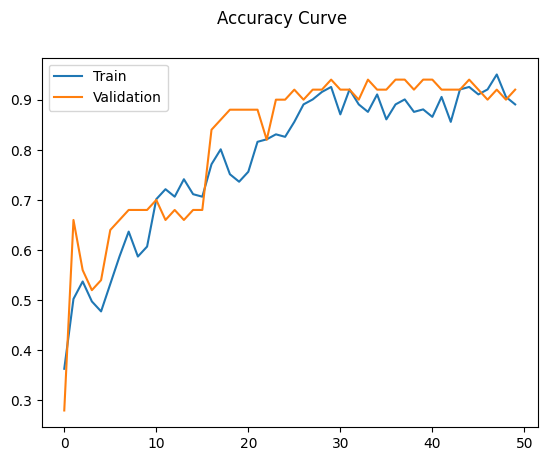

In [ ]:
plt.suptitle('Accuracy Curve')
plt.plot(hist.history['accuracy'], label='Train')
plt.plot(hist.history['val_accuracy'], label='Validation')
plt.legend()
plt.show()

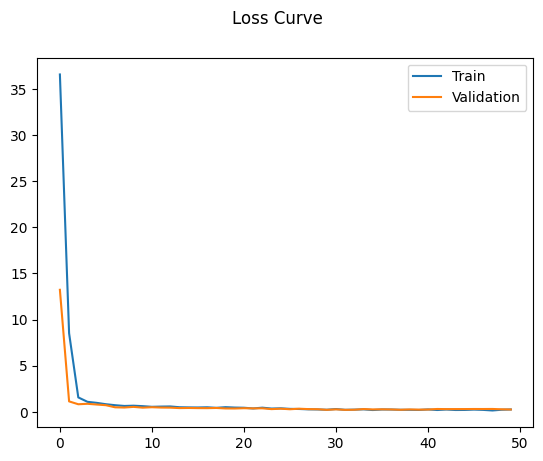

In [ ]:
plt.suptitle('Loss Curve')
plt.plot(hist.history['loss'], label='Train')
plt.plot(hist.history['val_loss'], label='Validation')
plt.legend()
plt.show()

1/1 [==============================] - 0s 86ms/step


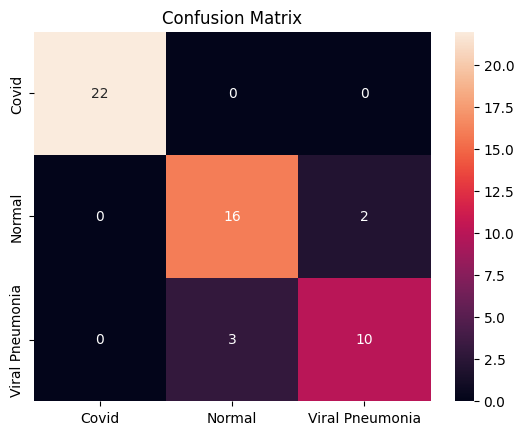

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import pandas as pd
import seaborn as sns
true_labels = []
predicted_labels = []

for images, labels in test_ds:
    true_labels.extend(np.argmax(labels, axis=1))
    predicted_labels.extend(np.argmax(model.predict(images), axis=1))

cm = confusion_matrix(true_labels, predicted_labels)
cm_df = pd.DataFrame(cm,
                     index = test_ds.class_names,
                     columns = test_ds.class_names)
sns.heatmap(cm_df, annot=True)

plt.title('Confusion Matrix')
classes = test_ds.class_names
plt.show()



In [ ]:
precision = precision_score(true_labels, predicted_labels, average='weighted')
recall = recall_score(true_labels, predicted_labels, average='weighted')
f1 = f1_score(true_labels, predicted_labels, average='weighted')

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

Precision: 0.9055
Recall: 0.9057
F1 Score: 0.9050
